# 異常分析 — 航行日報 / 養護事件

資料來源：`backend/hackathon-data/vt_fd.csv`（15 艘船 × 5 年航行日報）、`backend/hackathon-data/maintenance.csv`（77 筆養護事件）。

目標：先用非監督式方法（Isolation Forest）把「異常的一天」抓出來，因為我們沒有人工標記過的異常標籤，之後可以用抓出來的異常樣本，人工複核、標記後，再訓練監督式分類器。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = '../backend/hackathon-data'

## 1. 載入資料

**這一格在做什麼**：把兩份原始 CSV 讀進來。`vt_fd.csv` 是 15 艘船 5 年份的午報（每天一筆），`maintenance.csv` 是 77 筆養護事件紀錄。欄位名稱 `De-identification Name` 改成 `ship_id`，方便後面用同一個 key 跟 maintenance 資料合併。

In [3]:
vt = pd.read_csv(f'{DATA_DIR}/vt_fd.csv', low_memory=False)
maint = pd.read_csv(f'{DATA_DIR}/maintenance.csv', low_memory=False)

vt = vt.rename(columns={'De-identification Name': 'ship_id'})

print('vt_fd:', vt.shape)
print('maintenance:', maint.shape)
vt.head()

vt_fd: (21282, 40)
maintenance: (77, 9)


,ship_id,VOYAGE,NOON_UTC,AVG_SPEED,SPEED_THROUGH_WATER,ME_AVG_RPM,PROPELLER_SPEED,FORE_DRAFT,AFTER_DRAFT,DISPLACEMENT,CARGO_ON_BOARD,WIND_SCALE,SEA_HEIGHT,SEA_WATER_TEMP,WIND_SPEED,WIND_DIRECTION,SWELL_HEIGHT,SWELL_DIRECTION,SEA_DIRECTION,WATER_DEPTH,MID_DRAFT,TOTAL_DISTANCE,SEA_SPEED_DISTANCE,DIFF_STW_SOG_SLIP,FULL_SPD_STW_SLIP,HORSE_POWER,LOAD_PCT,SFOC,ME_SLIP,THRUST,THRUST_QUOTIENT,TOTAL_CONSUMP,ME_CONSUMPTION,ME_FULLSPEED_CONSUMP_HSHFO,ME_FULLSPEED_CONSUMP_ULSFO,ME_FULLSPEED_CONSUMP_VLSFO,ME_FULLSPEED_CONSUMP_LSMGO,ME_FULLSPEED_CONSUMP_BIO_HSFO,HOURS_FULL_SPEED,HOURS_TOTAL
0,S1,28,0,14.4,14.68,51.8,16.61,14.9,15.0,NaN,91791.0,3.0,NaN,NaN,NaN,12.0,NaN,NaN,NaN,20.0,NaN,329.0,317.0,NaN,NaN,13295.0,NaN,NaN,13.23,0.0,NaN,66.05,NaN,0.0,0.0,51.09,0.0,NaN,22.0,24.0
1,S1,28,0,14.4,14.68,51.8,16.61,14.9,15.0,NaN,91791.0,3.0,NaN,NaN,NaN,12.0,NaN,NaN,NaN,20.0,NaN,329.0,317.0,NaN,NaN,13295.0,NaN,NaN,13.2,0.0,NaN,66.05,NaN,0.0,0.0,51.09,0.0,NaN,22.0,24.0
2,S1,28,2,17.8,18.07,63.0,20.18,14.8,14.9,NaN,91661.0,6.0,NaN,NaN,NaN,6.0,NaN,NaN,NaN,225.0,NaN,357.0,351.0,NaN,NaN,23868.0,NaN,NaN,11.71,2337.0,NaN,93.51,NaN,0.0,0.0,80.3,0.0,NaN,19.7,24.0
3,S1,28,2,17.8,18.07,63.0,20.18,14.8,14.9,NaN,91661.0,6.0,NaN,NaN,NaN,6.0,NaN,NaN,NaN,225.0,NaN,357.0,351.0,NaN,NaN,23868.0,NaN,NaN,11.7,2337.0,NaN,93.51,NaN,0.0,0.0,80.3,0.0,NaN,19.7,24.0
4,S1,28,3,17.5,18.25,64.7,20.72,13.6,13.6,NaN,91661.0,3.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,1200.0,NaN,419.0,419.0,NaN,NaN,26898.0,NaN,NaN,15.75,2280.0,NaN,122.69,NaN,0.0,0.0,111.47,0.0,NaN,24.0,24.0


In [4]:
maint.head()

,ship_id,event_type,event_day,propeller_condition,hull_fouling_type,hull_coating_condition,cavitation_found,draft_fwd_m,draft_aft_m
0,S1,DD,981,NaN,NaN,NaN,NaN,NaN,NaN
1,S1,UWI+PP,1386,NaN,"barnacle,slime,algae",Good,NaN,13.6,13.8
2,S1,UWI+PP,1438,NaN,NaN,NaN,NaN,NaN,NaN
3,S1,PP,1560,Good,slime,NaN,No,10.8,12.0
4,S1,UWI+PP,1804,Good,"algae,barnacle,slime,calcium",NaN,Yes,12.1,13.0


## 2. 基本檢視

先看欄位型態、缺失率、船舶分布，確認資料乾淨到什麼程度（`vt_fd.csv` 的 A 類環境/航行欄位全部可見；H/T 類欄位在預測船 S21–S23 的遮蔽區間會是 `HIDDEN`/`PREDICT` 字串，轉數字時要注意會變成 NaN，這是預期行為不是資料錯誤）。

In [5]:
print('每艘船筆數：')
print(vt['ship_id'].value_counts().sort_index())
print()
print('缺失率前 15 名欄位：')
vt.isna().mean().sort_values(ascending=False).head(15)

每艘船筆數：
ship_id
S1     1482
S10    1427
S11    1500
S12    1396
S2     1483
S21    1456
S22    1453
S23    1429
S3     1342
S4     1486
S5     1444
S6     1386
S7     1348
S8     1471
S9     1179
Name: count, dtype: int64

缺失率前 15 名欄位：


ME_FULLSPEED_CONSUMP_BIO_HSFO    0.717696
MID_DRAFT                        0.314914
DISPLACEMENT                     0.314914
SEA_WATER_TEMP                   0.314491
ME_CONSUMPTION                   0.314444
THRUST_QUOTIENT                  0.195376
FULL_SPD_STW_SLIP                0.191335
SEA_DIRECTION                    0.183864
SEA_HEIGHT                       0.183864
WIND_SPEED                       0.183864
SWELL_HEIGHT                     0.183864
SWELL_DIRECTION                  0.183864
LOAD_PCT                         0.183535
SFOC                             0.183394
DIFF_STW_SOG_SLIP                0.183394
dtype: float64

In [6]:
# 數值欄位轉型（'HIDDEN' / 'PREDICT' 字串會被轉成 NaN，屬預期）
numeric_cols = [
    'AVG_SPEED', 'SPEED_THROUGH_WATER', 'ME_AVG_RPM', 'PROPELLER_SPEED',
    'FORE_DRAFT', 'AFTER_DRAFT', 'MID_DRAFT', 'DISPLACEMENT', 'CARGO_ON_BOARD',
    'WIND_SCALE', 'WIND_SPEED', 'SEA_HEIGHT', 'SWELL_HEIGHT', 'SEA_WATER_TEMP',
    'WATER_DEPTH', 'TOTAL_DISTANCE', 'SEA_SPEED_DISTANCE', 'DIFF_STW_SOG_SLIP',
    'FULL_SPD_STW_SLIP', 'HORSE_POWER', 'LOAD_PCT', 'SFOC', 'ME_SLIP',
    'THRUST', 'THRUST_QUOTIENT', 'TOTAL_CONSUMP', 'ME_CONSUMPTION',
    'HOURS_FULL_SPEED', 'HOURS_TOTAL', 'NOON_UTC', 'VOYAGE',
]
for col in numeric_cols:
    if col in vt.columns:
        vt[col] = pd.to_numeric(vt[col], errors='coerce')

## 3. Isolation Forest 異常分析

先用航行/環境相關特徵（A 類，訓練船 S1–S12 全部可見）做非監督異常偵測。`contamination` 先設 0.02（預期約 2% 的資料點是異常），之後可以照實際分布調整。

In [7]:
TRAIN_SHIPS = [f'S{i}' for i in range(1, 13)]
df = vt[vt['ship_id'].isin(TRAIN_SHIPS)].copy()

features = [
    'AVG_SPEED', 'SPEED_THROUGH_WATER', 'ME_AVG_RPM', 'PROPELLER_SPEED',
    'FORE_DRAFT', 'AFTER_DRAFT', 'MID_DRAFT', 'CARGO_ON_BOARD',
    'WIND_SCALE', 'SEA_HEIGHT', 'SWELL_HEIGHT', 'SEA_WATER_TEMP', 'WATER_DEPTH',
    'DIFF_STW_SOG_SLIP', 'FULL_SPD_STW_SLIP', 'HOURS_FULL_SPEED',
]

model_df = df.dropna(subset=features).copy()
X = model_df[features]
X_scaled = StandardScaler().fit_transform(X)

print(f'可用樣本數: {len(model_df)} / {len(df)}')

可用樣本數: 11489 / 16944


In [8]:
iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42, n_jobs=-1)
model_df['anomaly'] = iso.fit_predict(X_scaled)          # -1 = 異常, 1 = 正常
model_df['anomaly_score'] = iso.decision_function(X_scaled)  # 越低越異常

print(model_df['anomaly'].value_counts())

anomaly
 1    11259
-1      230
Name: count, dtype: int64


## 4. 看看抓到的異常

分數最低（最異常）的前 20 筆，跟該船的養護事件時間對照，看異常是不是集中在養護事件附近（例如船殼/螺旋槳剛開始劣化或剛清潔完試俥時）。

In [9]:
top_anomalies = model_df.sort_values('anomaly_score').head(20)
top_anomalies[['ship_id', 'NOON_UTC', 'VOYAGE'] + features + ['anomaly_score']]

,ship_id,NOON_UTC,VOYAGE,AVG_SPEED,SPEED_THROUGH_WATER,ME_AVG_RPM,PROPELLER_SPEED,FORE_DRAFT,AFTER_DRAFT,MID_DRAFT,CARGO_ON_BOARD,WIND_SCALE,SEA_HEIGHT,SWELL_HEIGHT,SEA_WATER_TEMP,WATER_DEPTH,DIFF_STW_SOG_SLIP,FULL_SPD_STW_SLIP,HOURS_FULL_SPEED,anomaly_score
6903,S10,1741,47,6.9,7.89,36.7,0.01,13.30,15.00,13.70,51621.0,6.0,5.0,4.0,8.0,1500.0,8536.364,-71600.000,21.3,-0.097311
6926,S10,1773,47,9.3,9.58,36.9,0.01,10.50,11.90,10.90,51621.0,7.0,4.0,4.5,4.0,2500.0,2645.455,-87018.182,24.0,-0.090958
6902,S10,1740,47,11.8,13.00,53.0,0.02,13.30,15.00,13.70,51621.0,10.0,6.0,6.0,6.0,1200.0,7550.000,-81150.000,24.0,-0.090019
6738,S10,1524,44,19.9,20.32,65.4,0.02,11.87,12.33,11.76,67265.0,9.0,5.0,2.0,2.0,2000.0,2000.000,-101500.000,25.0,-0.087752
6669,S10,1427,43,17.5,17.75,6.0,0.00,14.02,14.11,13.63,94378.0,7.0,3.0,4.0,6.0,5000.0,10400.000,-887400.000,24.0,-0.087528
20505,S8,841,37,2.0,3.00,23.3,7.46,5.10,10.20,7.30,0.0,2.0,0.1,0.3,30.0,70.0,13.402,59.796,0.5,-0.087380
6734,S10,1520,44,18.0,18.64,62.3,0.02,11.87,12.33,11.76,67265.0,8.0,4.0,5.0,6.0,3500.0,3368.421,-98005.263,25.0,-0.086224
6901,S10,1739,47,16.6,16.96,58.8,0.02,13.20,15.00,13.60,51621.0,11.0,6.0,6.0,4.0,1200.0,2177.778,-94105.556,23.0,-0.085345
6929,S10,1776,47,12.8,12.56,41.9,0.01,10.50,11.90,10.90,51621.0,9.0,5.0,5.0,2.0,2500.0,-1846.153,-96515.385,25.0,-0.084791
6921,S10,1768,47,9.8,10.00,38.0,0.01,10.50,11.90,10.90,51621.0,8.0,4.0,5.0,6.0,2500.0,1733.333,-83233.333,24.0,-0.084311


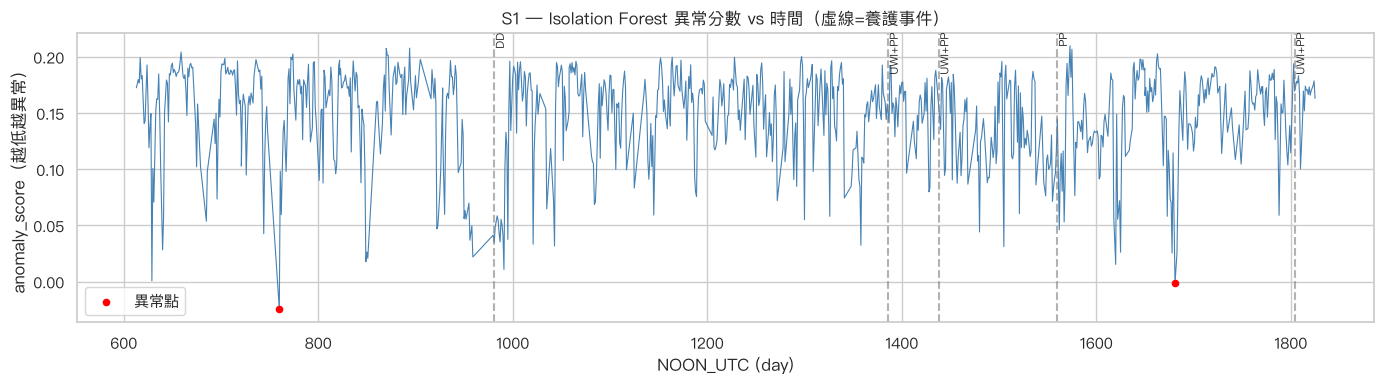

In [10]:
# 異常分數隨時間分布，疊上養護事件（垂直虛線），看異常是否跟養護時間點對應
ship_id = 'S1'
ship_df = model_df[model_df['ship_id'] == ship_id].sort_values('NOON_UTC')
ship_maint = maint[maint['ship_id'] == ship_id]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ship_df['NOON_UTC'], ship_df['anomaly_score'], lw=0.8, color='steelblue')
ax.scatter(
    ship_df.loc[ship_df['anomaly'] == -1, 'NOON_UTC'],
    ship_df.loc[ship_df['anomaly'] == -1, 'anomaly_score'],
    color='red', s=20, zorder=5, label='異常點',
)
for _, row in ship_maint.iterrows():
    ax.axvline(row['event_day'], color='gray', ls='--', alpha=0.6)
    ax.text(row['event_day'], ax.get_ylim()[1], row['event_type'], rotation=90, fontsize=8, va='top')
ax.set_title(f'{ship_id} — Isolation Forest 異常分數 vs 時間（虛線=養護事件）')
ax.set_xlabel('NOON_UTC (day)')
ax.set_ylabel('anomaly_score（越低越異常）')
ax.legend()
plt.tight_layout()
plt.show()

## 5. 下一步（分類）

Isolation Forest 是非監督式，先拿它抓出的異常樣本人工複核幾筆、標記「真異常」vs「誤判」，就能把 `anomaly` 欄位當初步標籤，訓練監督式分類器（例如 RandomForestClassifier / XGBClassifier）——這樣之後新資料進來可以直接分類，不用每次重跑 Isolation Forest。也可以把 `maintenance.csv` 的事件類型/日期當弱標籤，看異常點是否集中在特定養護事件前後，藉此驗證異常偵測抓到的是不是真的船體/螺旋槳劣化訊號，而不是感測器雜訊。

## 6. 油耗異常根因分析

前面的 Isolation Forest 是對「一般航行狀態」抓異常，這裡換個角度：專門針對**油耗**——先建一個只用操作條件（轉速、船速、吃水、天氣、載重）預測「這個操作條件下應該燒多少油」的基準模型，殘差（實際 − 預期）大的就是「油耗異常」。因為基準模型完全不知道船殼/螺旋槳的養護狀態，殘差如果真的跟養護狀態相關，就是很乾淨的根因證據，不是模型自己學到的循環論證。

### 6.1 計算每日油耗（Daily FOC）

`vt_fd.csv` 裡油耗欄位有 5 個（`ME_FULLSPEED_CONSUMP_HSHFO/VLSFO/ULSFO/LSMGO/BIO_HSFO`），但同一天只有**當天實際用的那種燃料**有數值，其他都是 0。這一格做兩件事：
1. 找出當天用的是哪種燃料（5 欄裡數值最大的那個）
2. 用熱值（LCV）換算成統一的 VLSFO 當量，再用 `HOURS_FULL_SPEED` 正規化成「等效 24 小時全速油耗」——這個公式是主辦單位命題簡報裡直接給的（`Daily FOC = ME_FULLSPEED_CONSUMP_VLSFO ÷ HOURS_FULL_SPEED × 24`），不是我們自己發明的。

`HOURS_FULL_SPEED < 22` 的日子（沒有跑到「穩態全速」）回傳 `NaN`，不納入計算——因為非全速日的油耗跟操作條件的關係太雜訊，會污染後面的基準模型。

In [11]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

FUEL_LCV = {
    'ME_FULLSPEED_CONSUMP_HSHFO': 40.2, 'ME_FULLSPEED_CONSUMP_VLSFO': 40.2,
    'ME_FULLSPEED_CONSUMP_ULSFO': 41.2, 'ME_FULLSPEED_CONSUMP_LSMGO': 42.7,
    'ME_FULLSPEED_CONSUMP_BIO_HSFO': 39.4,
}
FUEL_COLS = list(FUEL_LCV.keys())

for col in FUEL_COLS:
    vt[col] = pd.to_numeric(vt[col], errors='coerce')

def compute_daily_foc(row):
    best_col, best_val = None, 0
    for c in FUEL_COLS:
        v = row[c]
        if pd.notna(v) and v > best_val:
            best_val, best_col = v, c
    if best_col is None or row['HOURS_FULL_SPEED'] is None or pd.isna(row['HOURS_FULL_SPEED']) or row['HOURS_FULL_SPEED'] < 22:
        return np.nan
    return best_val * (FUEL_LCV[best_col] / 40.2) / row['HOURS_FULL_SPEED'] * 24.0

vt['daily_foc'] = vt.apply(compute_daily_foc, axis=1)
print('有效 daily_foc 筆數:', vt['daily_foc'].notna().sum())

有效 daily_foc 筆數: 14159


### 6.2 篩出「乾淨」分析母體

只留：① 訓練船 S1–S12（資料完全公開，沒有遮蔽）② 風力 ≤4 級（穩態篩選條件，天氣太差時船速/油耗關係會被風浪主導，不是我們要分析的養護狀態訊號）③ `daily_foc` 算得出來且不小於 10（排除掉資料異常或非全速的殘留噪音）。這組資料就是後面所有分析的母體，樣本數會印出來。

In [12]:
# calm condition + 訓練船，作為根因分析母體
calm = vt[
    (vt['ship_id'].isin(TRAIN_SHIPS)) &
    (vt['WIND_SCALE'] <= 4) &
    (vt['daily_foc'].notna()) & (vt['daily_foc'] >= 10)
].copy()
print('calm 樣本數:', len(calm))
calm[['ship_id','NOON_UTC','daily_foc','ME_AVG_RPM','SPEED_THROUGH_WATER']].head()

calm 樣本數: 6454


,ship_id,NOON_UTC,daily_foc,ME_AVG_RPM,SPEED_THROUGH_WATER
0,S1,0,55.734545,51.8,14.68
1,S1,0,55.734545,51.8,14.68
4,S1,3,111.470000,64.7,18.25
8,S1,6,107.310000,64.3,18.88
9,S1,7,99.245217,62.5,18.35


### 6.3 幫每一筆午報，接上「當時的養護狀態」

這是根因分析能不能成立的關鍵一步：對午報裡的每一天，往回找**這艘船在這一天當下**，距離上次清船殼／拋螺旋槳分別過了幾天，還有上次檢查記錄的汙損種類、螺旋槳狀態。

注意這是「as-of」查詢——同一艘船不同天，`days_since_hull_clean` 會不一樣，因為隨著天數增加、又還沒下次養護，這個數字會一直往上累加，遇到下次同類型養護事件才會歸零重算。如果這艘船在這天之前完全沒有過對應類型的養護紀錄，就用「這天本身的天數」當替代值（相當於假設從資料起點就開始累積）。

這一步是逐列 `apply`，資料量大的時候會跑一陣子，屬正常現象。

In [13]:
# ── 養護紀錄衍生特徵：距上次船殼清潔/螺旋槳拋光天數、上次汙損種類、螺旋槳狀態 ──
HULL_CLEAN_TYPES = {'DD', 'UWC', 'UWC+PP'}
PROP_POLISH_TYPES = {'DD', 'PP', 'UWI+PP', 'UWC+PP'}

maint_sorted = maint.sort_values(['ship_id', 'event_day']).copy()

def maint_features_for_row(ship_id, day):
    ship_events = maint_sorted[maint_sorted['ship_id'] == ship_id]
    prior = ship_events[ship_events['event_day'] <= day]
    hull_prior = prior[prior['event_type'].isin(HULL_CLEAN_TYPES)]
    prop_prior = prior[prior['event_type'].isin(PROP_POLISH_TYPES)]
    days_since_hull = day - hull_prior['event_day'].max() if len(hull_prior) else day
    days_since_prop = day - prop_prior['event_day'].max() if len(prop_prior) else day
    last_fouling = prior.iloc[-1]['hull_fouling_type'] if len(prior) else np.nan
    last_prop_cond = prior.iloc[-1]['propeller_condition'] if len(prior) else np.nan
    return pd.Series({
        'days_since_hull_clean': days_since_hull,
        'days_since_prop_polish': days_since_prop,
        'last_hull_fouling_type': last_fouling,
        'last_propeller_condition': last_prop_cond,
    })

maint_feats = calm.apply(lambda r: maint_features_for_row(r['ship_id'], r['NOON_UTC']), axis=1)
calm = pd.concat([calm, maint_feats], axis=1)
calm[['ship_id','NOON_UTC','days_since_hull_clean','days_since_prop_polish','last_hull_fouling_type','last_propeller_condition']].head()

,ship_id,NOON_UTC,days_since_hull_clean,days_since_prop_polish,last_hull_fouling_type,last_propeller_condition
0,S1,0,0.0,0.0,NaN,NaN
1,S1,0,0.0,0.0,NaN,NaN
4,S1,3,3.0,3.0,NaN,NaN
8,S1,6,6.0,6.0,NaN,NaN
9,S1,7,7.0,7.0,NaN,NaN


### 6.4 建立「基準油耗模型」——只看操作條件，完全不知道養護狀態

這是整個根因分析的核心設計：訓練一個 RandomForest，輸入**只有**轉速、船速、吃水、載重、天氣這些「當下操作條件」，完全不給它任何養護相關的欄位（不給 `days_since_hull_clean` 等）。

為什麼要這樣做：如果讓模型同時看到操作條件跟養護狀態，模型會自己把兩者混在一起解釋油耗，我們就沒辦法乾淨地說「養護狀態單獨造成多少影響」。故意讓模型「不知道」船殼髒不髒，它就只能學到「這個轉速/船速/載重下，物理上應該燒多少油」——之後實際油耗跟這個預測值的差（殘差），才能真正歸因給模型看不到的東西：也就是養護狀態。

`R²` 越接近 1 代表操作條件對油耗的解釋力越強（測試集上通常會到 0.95 左右，跟前面 v5 model 發現「RPM 幾乎主導油耗」的結論一致）；`MAE` 是預測誤差的平均絕對值（單位 MT/day），拿來對照油耗量級（通常 50-100 MT/day）才知道誤差算不算大。

In [14]:
# ── 基準模型：只用「操作條件」預測預期油耗，完全不含養護狀態 ──
OP_FEATURES = ['ME_AVG_RPM', 'SPEED_THROUGH_WATER', 'AVG_SPEED', 'FORE_DRAFT', 'AFTER_DRAFT',
               'CARGO_ON_BOARD', 'WIND_SCALE', 'SEA_HEIGHT', 'SWELL_HEIGHT', 'SEA_WATER_TEMP']

model_data = calm.dropna(subset=OP_FEATURES + ['daily_foc']).copy()
Xop = model_data[OP_FEATURES]
y = model_data['daily_foc']

Xtr, Xte, ytr, yte = train_test_split(Xop, y, test_size=0.2, random_state=42)
baseline_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
baseline_model.fit(Xtr, ytr)
pred_te = baseline_model.predict(Xte)
print(f'基準模型（只用操作條件）測試集: R2={r2_score(yte, pred_te):.3f}  MAE={mean_absolute_error(yte, pred_te):.2f} MT/day')

model_data['predicted_foc'] = baseline_model.predict(Xop)
model_data['residual'] = model_data['daily_foc'] - model_data['predicted_foc']
model_data['residual_pct'] = model_data['residual'] / model_data['predicted_foc'] * 100

基準模型（只用操作條件）測試集: R2=0.953  MAE=3.82 MT/day


### 6.5 標記「油耗異常」

`residual_pct = (實際油耗 − 預期油耗) ÷ 預期油耗 × 100`，正值代表「比操作條件該有的燒更多油」，負值代表「燒得比預期少」。門檻先抓 ±15%（可依下面畫出來的分布圖調整——如果分布很集中、±15% 抓太多或太少，就改數字重跑這一格跟下一格就好，不用整份重跑）。

is_anomaly
False    4158
True      423
Name: count, dtype: int64
異常比例: 9.2%


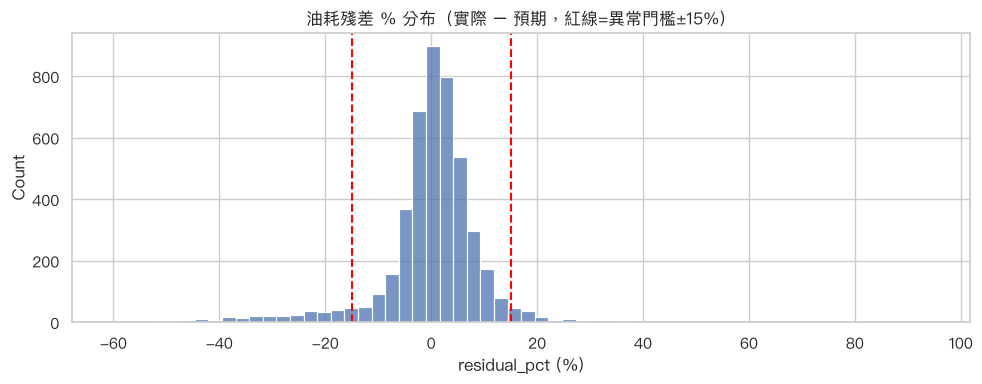

In [15]:
# ── 標記異常：殘差絕對值超過 ±15% 視為油耗異常 ──
THRESH = 15
model_data['is_anomaly'] = model_data['residual_pct'].abs() > THRESH
print(model_data['is_anomaly'].value_counts())
print(f"異常比例: {model_data['is_anomaly'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(10,4))
sns.histplot(model_data['residual_pct'], bins=60, ax=ax)
ax.axvline(THRESH, color='red', ls='--'); ax.axvline(-THRESH, color='red', ls='--')
ax.set_title('油耗殘差 % 分布（實際 − 預期，紅線=異常門檻±15%）')
ax.set_xlabel('residual_pct (%)')
plt.tight_layout(); plt.show()

## 7. 根因：異常 vs 正常，養護狀態差在哪

先看分布，再用一個小模型排出「哪個養護/天候特徵最能解釋殘差」——這個模型只吃根因候選特徵（不吃操作條件，因為操作條件已經被基準模型吸收掉了），直接看 feature importance 就是根因排名。

### 7.1 異常組 vs 正常組，養護天數差多少

這裡用 `is_anomaly`（二元標籤：True/False）分組比較。**要注意的解讀陷阱**：`is_anomaly` 把「燒太多」跟「燒太少」兩種完全相反的異常混在同一組裡，如果這兩種異常各自跟養護天數的關係方向不同，平均值會互相抵消、看起來像「沒差別」。真正乾淨的根因訊號在下面 7.3 的迴歸模型（直接對連續值 `residual_pct` 做回歸，不做二元切分）。這裡的圖/表比較像是初步視覺化，不是最終結論。

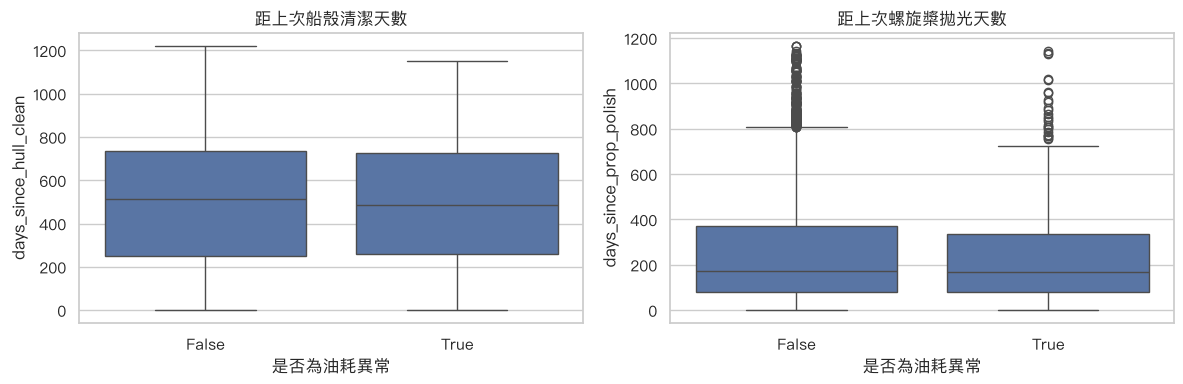

正常 vs 異常 平均值比較：
            days_since_hull_clean  days_since_prop_polish  residual_pct
is_anomaly                                                             
False                  503.214045              271.379269      1.123782
True                   496.430260              241.132388    -12.209955


In [16]:
# ── 分布比較：異常 vs 正常，距上次清潔/拋光天數 ──
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col, title in zip(axes, ['days_since_hull_clean','days_since_prop_polish'], ['距上次船殼清潔天數','距上次螺旋槳拋光天數']):
    sns.boxplot(data=model_data, x='is_anomaly', y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('是否為油耗異常')
plt.tight_layout(); plt.show()

print('正常 vs 異常 平均值比較：')
print(model_data.groupby('is_anomaly')[['days_since_hull_clean','days_since_prop_polish','residual_pct']].mean())

### 7.1b 拆開「燒太多」跟「燒太少」，分開看

上面二元標籤把兩個方向的異常混在一起可能互相抵消訊號，這裡改成三組：`over`（`residual_pct > +15`，燒得比預期多）、`under`（`residual_pct < -15`，燒得比預期少）、`normal`（其餘）。分別比較三組的養護天數分布，再各自對 `over`/`under` 兩個子集單獨做一次根因迴歸（跟 7.3 同一套模型，只是分開跑），看驅動因素是不是真的不一樣。

In [17]:
THRESH = 15
model_data['direction'] = np.select(
    [model_data['residual_pct'] > THRESH, model_data['residual_pct'] < -THRESH],
    ['over', 'under'],
    default='normal',
)
print(model_data['direction'].value_counts())
print()
print('三組平均值比較：')
print(model_data.groupby('direction')[['days_since_hull_clean', 'days_since_prop_polish', 'residual_pct']].mean())

direction
normal    4158
under      295
over       128
Name: count, dtype: int64

三組平均值比較：
           days_since_hull_clean  days_since_prop_polish  residual_pct
direction                                                             
normal                503.214045              271.379269      1.123782
over                  522.195312              260.312500     22.264310
under                 485.250847              232.810169    -27.168280


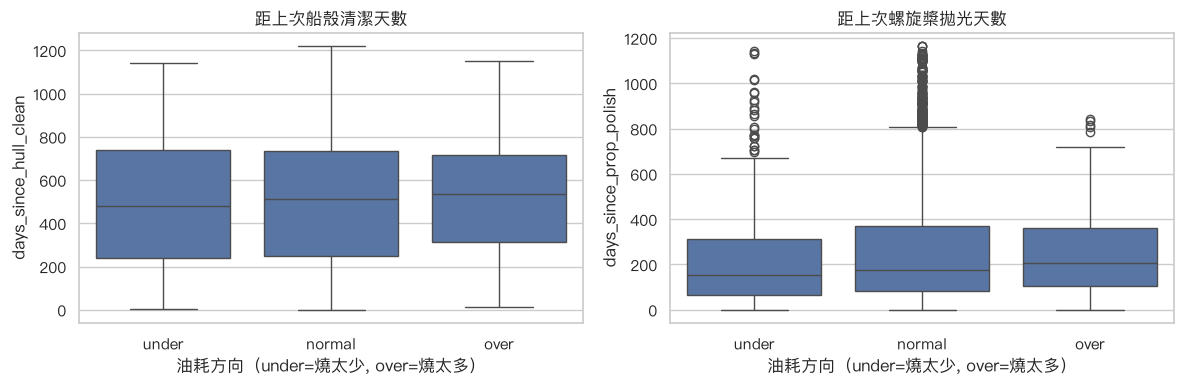

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
order = ['under', 'normal', 'over']
for ax, col, title in zip(axes, ['days_since_hull_clean','days_since_prop_polish'], ['距上次船殼清潔天數','距上次螺旋槳拋光天數']):
    sns.boxplot(data=model_data, x='direction', y=col, order=order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('油耗方向（under=燒太少, over=燒太多）')
plt.tight_layout(); plt.show()

### 7.1c 分開跑根因迴歸——over 組跟 under 組的驅動因素是不是不一樣

如果 `over`（燒太多）真的是船殼/螺旋槳汙損造成，養護天數的 feature importance 在這組應該會比在 `under`（燒太少）組明顯更高——`under` 組理論上比較可能是別的原因（例如順流、輕載、資料誤差），養護天數對它的解釋力應該較弱。

over（n=128）:
days_since_prop_polish      0.265101
days_since_hull_clean       0.252393
SEA_WATER_TEMP              0.245349
SWELL_HEIGHT                0.100357
SEA_HEIGHT                  0.072668
WIND_SCALE                  0.043172
propeller_condition_code    0.020961
dtype: float64

under（n=295）:
days_since_hull_clean       0.278469
days_since_prop_polish      0.233151
SEA_WATER_TEMP              0.196189
SWELL_HEIGHT                0.099059
SEA_HEIGHT                  0.088675
WIND_SCALE                  0.078288
propeller_condition_code    0.026167
dtype: float64



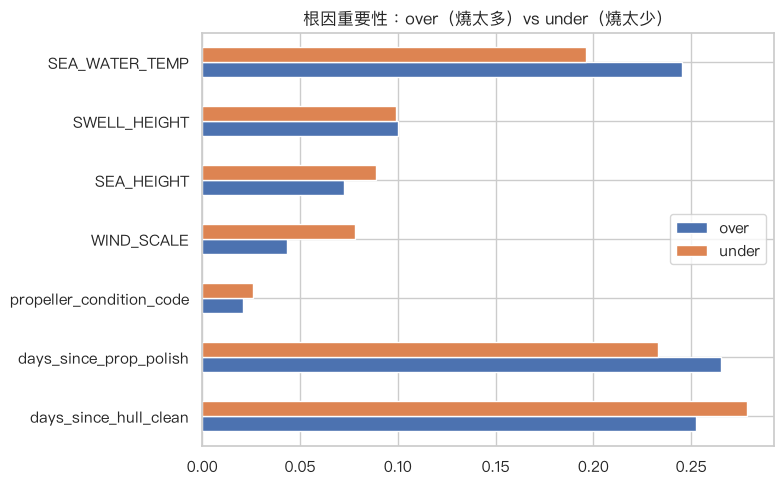

In [19]:
root_cause_df = model_data.copy()
root_cause_df['last_propeller_condition'] = root_cause_df['last_propeller_condition'].fillna('Unknown')
from sklearn.preprocessing import LabelEncoder
root_cause_df['propeller_condition_code'] = LabelEncoder().fit_transform(root_cause_df['last_propeller_condition'])

ROOT_CAUSE_FEATURES = ['days_since_hull_clean', 'days_since_prop_polish', 'propeller_condition_code',
                       'WIND_SCALE', 'SEA_HEIGHT', 'SWELL_HEIGHT', 'SEA_WATER_TEMP']

importances_by_direction = {}
for direction in ['over', 'under']:
    subset = root_cause_df[root_cause_df['direction'] == direction].dropna(subset=ROOT_CAUSE_FEATURES + ['residual_pct'])
    if len(subset) < 20:
        print(f'{direction}: 樣本數太少（{len(subset)}），跳過')
        continue
    m = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
    m.fit(subset[ROOT_CAUSE_FEATURES], subset['residual_pct'])
    importances_by_direction[direction] = pd.Series(m.feature_importances_, index=ROOT_CAUSE_FEATURES)
    print(f'{direction}（n={len(subset)}）:')
    print(importances_by_direction[direction].sort_values(ascending=False))
    print()

if len(importances_by_direction) == 2:
    comp = pd.DataFrame(importances_by_direction)
    fig, ax = plt.subplots(figsize=(8,5))
    comp.plot(kind='barh', ax=ax)
    ax.set_title('根因重要性：over（燒太多）vs under（燒太少）')
    plt.tight_layout(); plt.show()

### 7.2 汙損種類 vs 殘差——驗證資料是否符合海事常識

`hull_fouling_type` 欄位是逗號分隔的複合字串（例如 `"barnacle,slime,algae"` 代表這次檢查同時發現三種附著物），先用 `explode` 展開成一列一種，才能個別算每種附著物對應的平均殘差。這步主要是拿來做**物理合理性檢查**：藤壺（barnacle）、管蟲（tubeworm）這類硬殼附着物理論上比黏膜（slime）造成更大阻力，如果算出來的排序跟這個常識吻合，就是對整條分析管線的一個交叉驗證，不是巧合。

                  mean  count
fouling_list                 
tubeworm      5.964448    133
algae         1.372934   1025
barnacle      0.593706   1723
slime         0.478326   2092
calcium      -0.789058    719


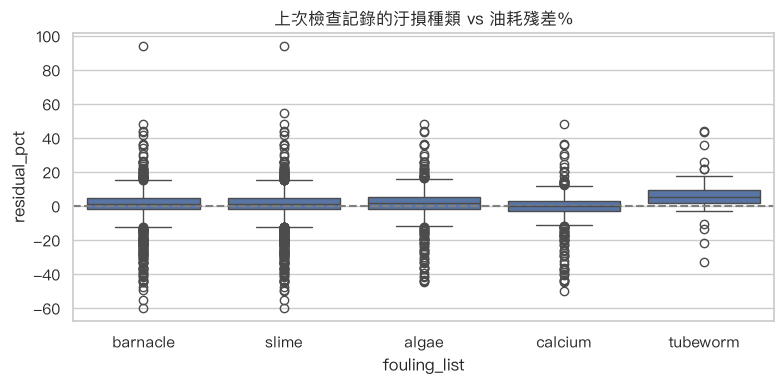

In [20]:
# ── 汙損種類 vs 殘差：哪種附著物對應的油耗異常幅度最大 ──
fouling_expanded = model_data.dropna(subset=['last_hull_fouling_type']).copy()
fouling_expanded['fouling_list'] = fouling_expanded['last_hull_fouling_type'].str.split(',')
fouling_long = fouling_expanded.explode('fouling_list')
fouling_long['fouling_list'] = fouling_long['fouling_list'].str.strip()

fouling_summary = fouling_long.groupby('fouling_list')['residual_pct'].agg(['mean','count']).sort_values('mean', ascending=False)
print(fouling_summary)

fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=fouling_long, x='fouling_list', y='residual_pct', ax=ax)
ax.axhline(0, color='gray', ls='--')
ax.set_title('上次檢查記錄的汙損種類 vs 油耗殘差%')
plt.tight_layout(); plt.show()

### 7.3 根因排名——真正的定量結論

跟前面基準模型（6.4）刻意相反：這個模型**只吃候選根因特徵**（養護天數、螺旋槳狀態、天氣），完全不給操作條件（轉速/船速那些），去預測 `residual_pct`（連續值，不做二元切分）。`feature_importances_` 就直接是「這個因素能解釋多少油耗異常」的定量排名——這張圖是整個 notebook 最重要的產出，可以直接拿去回答「為什麼有些天油耗特別高/低」。

根因特徵重要性（預測油耗殘差%）：
days_since_prop_polish      0.322749
days_since_hull_clean       0.256683
SWELL_HEIGHT                0.150240
SEA_WATER_TEMP              0.114017
SEA_HEIGHT                  0.071604
WIND_SCALE                  0.045083
propeller_condition_code    0.039624
dtype: float64


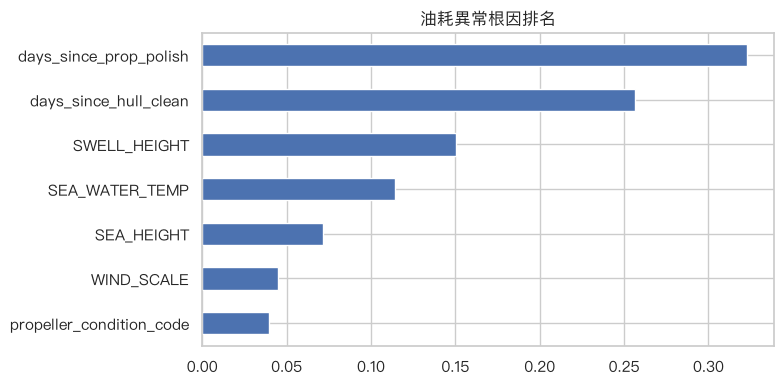

In [21]:
# ── 根因排名：小模型只吃候選根因特徵，預測殘差%，看 feature importance ──
from sklearn.preprocessing import LabelEncoder

root_cause_df = model_data.copy()
root_cause_df['last_propeller_condition'] = root_cause_df['last_propeller_condition'].fillna('Unknown')
prop_le = LabelEncoder()
root_cause_df['propeller_condition_code'] = prop_le.fit_transform(root_cause_df['last_propeller_condition'])

ROOT_CAUSE_FEATURES = ['days_since_hull_clean', 'days_since_prop_polish', 'propeller_condition_code',
                       'WIND_SCALE', 'SEA_HEIGHT', 'SWELL_HEIGHT', 'SEA_WATER_TEMP']

rc_data = root_cause_df.dropna(subset=ROOT_CAUSE_FEATURES + ['residual_pct'])
Xrc = rc_data[ROOT_CAUSE_FEATURES]
yrc = rc_data['residual_pct']

rc_model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
rc_model.fit(Xrc, yrc)

importance = pd.Series(rc_model.feature_importances_, index=ROOT_CAUSE_FEATURES).sort_values(ascending=False)
print('根因特徵重要性（預測油耗殘差%）：')
print(importance)

fig, ax = plt.subplots(figsize=(8,4))
importance.plot(kind='barh', ax=ax)
ax.set_title('油耗異常根因排名')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 8. 結論範本

跑完以上，重點看：
1. `residual_pct` 分布 — 異常門檻抓得合不合理（±15% 只是起始值，可依實際分布調整）
2. 異常 vs 正常的 `days_since_hull_clean` / `days_since_prop_polish` 平均值差多少 — 差越大代表養護狀態確實是主要根因
3. `fouling_summary` — 哪種汙損種類（barnacle/slime/algae/tubeworm/calcium）對應的油耗殘差最高，藤壺類通常該比黏膜類更嚴重，可以驗證資料是否符合物理直覺
4. 根因排名長條圖 — 定量告訴你「距上次清船殼天數」vs「天候」誰對油耗異常的貢獻更大，這是能直接放進簡報「商務決策價值」那頁的圖

## 9. 成因分類——每一天的油耗異常，主要是哪個原因造成的

前面的 feature importance 只回答「平均來說哪個因素最重要」，沒辦法回答「這艘船這一天油耗異常偏高，具體是哪個原因」。這裡改用 **SHAP**（SHapley Additive exPlanations）——對根因迴歸模型的每一筆預測，把預測值拆解成每個特徵各自貢獻多少，這樣就能對**每一天**分別判斷主因，而不只是整體平均排名。

做法：
1. 針對「燒太多」（`over`，`residual_pct > +15%`）的那 128 天，用根因模型算出每個特徵的 SHAP 值
2. 把 7 個候選根因特徵歸成 3 類：**船殼**（`days_since_hull_clean`）、**螺旋槳**（`days_since_prop_polish` + `propeller_condition_code`）、**天候**（風力/浪高/湧浪/水溫）
3. 每一天，看哪一類的 SHAP 貢獻加總最大（正值=把預測往「異常偏高」的方向推），那一類就是這一天的主因
4. 統計三類主因各佔多少比例——這就是「成因分類」的結果

In [22]:
import shap

CAUSE_GROUPS = {
    '船殼汙損': ['days_since_hull_clean'],
    '螺旋槳汙損': ['days_since_prop_polish', 'propeller_condition_code'],
    '天候': ['WIND_SCALE', 'SEA_HEIGHT', 'SWELL_HEIGHT', 'SEA_WATER_TEMP'],
}

over_subset = root_cause_df[root_cause_df['direction'] == 'over'].dropna(subset=ROOT_CAUSE_FEATURES + ['residual_pct']).copy()
X_over = over_subset[ROOT_CAUSE_FEATURES]

# 用全體資料重新 fit 一個乾淨、獨立保存的模型（避免依賴前面迴圈裡被覆寫的變數）
over_cause_model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
over_cause_model.fit(root_cause_df.dropna(subset=ROOT_CAUSE_FEATURES+['residual_pct'])[ROOT_CAUSE_FEATURES],
                      root_cause_df.dropna(subset=ROOT_CAUSE_FEATURES+['residual_pct'])['residual_pct'])

explainer = shap.TreeExplainer(over_cause_model)
shap_values = explainer.shap_values(X_over)  # shape: (n_days, n_features)

shap_df = pd.DataFrame(shap_values, columns=ROOT_CAUSE_FEATURES, index=X_over.index)
print(f'算完 {len(shap_df)} 天的 SHAP 值')
shap_df.head()

算完 128 天的 SHAP 值


,days_since_hull_clean,days_since_prop_polish,propeller_condition_code,WIND_SCALE,SEA_HEIGHT,SWELL_HEIGHT,SEA_WATER_TEMP
592,0.619858,0.058586,0.015466,0.231784,0.056981,1.476151,-0.010010
686,0.422839,0.660773,-0.060798,-0.031953,-0.047444,-0.392174,0.007029
692,1.355772,1.612215,-0.066305,0.022394,0.131644,-0.062707,0.091114
817,1.487819,1.400873,0.044212,0.088332,0.078572,6.188466,0.253136
892,-0.196707,0.582001,0.056551,-0.099222,0.122077,-0.411089,0.263328


油耗異常偏高的天數，主因分類：
  螺旋槳汙損: 72 天 (56.2%)
  天候: 32 天 (25.0%)
  船殼汙損: 24 天 (18.8%)


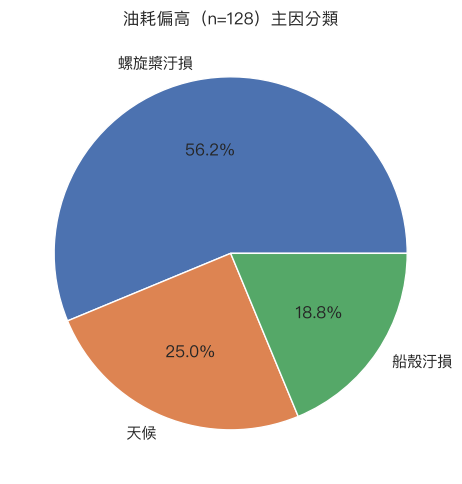

In [23]:
# 把 7 個特徵的 SHAP 貢獻，歸到 3 個成因類別，每天挑貢獻最大的類別當主因
group_shap = pd.DataFrame({
    group: shap_df[cols].sum(axis=1) for group, cols in CAUSE_GROUPS.items()
})
over_subset['primary_cause'] = group_shap.idxmax(axis=1)
over_subset['primary_cause_shap'] = group_shap.max(axis=1)

cause_breakdown = over_subset['primary_cause'].value_counts()
cause_pct = (cause_breakdown / len(over_subset) * 100).round(1)
print('油耗異常偏高的天數，主因分類：')
for cause in cause_breakdown.index:
    print(f'  {cause}: {cause_breakdown[cause]} 天 ({cause_pct[cause]}%)')

fig, ax = plt.subplots(figsize=(6,5))
cause_breakdown.plot(kind='pie', autopct='%1.1f%%', ax=ax, ylabel='')
ax.set_title(f'油耗偏高（n={len(over_subset)}）主因分類')
plt.tight_layout(); plt.show()

### 9.1 個別案例檢視

挑幾筆主因最明確（SHAP 貢獻最大）的天，看實際數值——這是「可以指著給評審看」的具體案例，比只講統計數字更有說服力。

In [24]:
example_cols = ['ship_id', 'NOON_UTC', 'residual_pct', 'primary_cause', 'primary_cause_shap',
                'days_since_hull_clean', 'days_since_prop_polish', 'last_propeller_condition',
                'WIND_SCALE', 'SEA_HEIGHT', 'SWELL_HEIGHT', 'SEA_WATER_TEMP']
over_subset.sort_values('primary_cause_shap', ascending=False)[example_cols].head(10)

,ship_id,NOON_UTC,residual_pct,primary_cause,primary_cause_shap,days_since_hull_clean,days_since_prop_polish,last_propeller_condition,WIND_SCALE,SEA_HEIGHT,SWELL_HEIGHT,SEA_WATER_TEMP
9348,S12,1197,20.004113,天候,6.613112,30.0,30.0,Poor,4.0,1.5,4.5,24.0
817,S1,1023,15.433049,天候,6.608506,42.0,42.0,Unknown,3.0,0.5,4.5,21.0
6443,S10,1152,47.922045,船殼汙損,6.296696,1152.0,220.0,Poor,2.0,0.3,0.0,12.0
21082,S8,1563,94.036032,天候,6.279370,761.0,294.0,Unknown,3.0,0.5,0.8,13.0
20750,S8,1141,56.113756,天候,4.321624,339.0,339.0,Unknown,4.0,1.5,2.5,16.0
19744,S7,1737,41.720309,螺旋槳汙損,4.145564,876.0,236.0,Good,1.0,0.0,0.5,30.0
20749,S8,1140,23.059041,天候,3.484966,338.0,338.0,Unknown,4.0,1.5,2.5,16.0
1249,S1,1560,18.891964,螺旋槳汙損,3.365075,579.0,0.0,Good,2.0,0.2,0.0,14.0
9537,S12,1404,25.247946,天候,2.821499,99.0,93.0,Unknown,4.0,1.5,3.0,25.0
3733,S9,1004,17.374776,天候,2.793448,1004.0,79.0,Unknown,3.0,1.0,2.5,15.0


In [29]:
over_subset.to_csv('./test.csv')

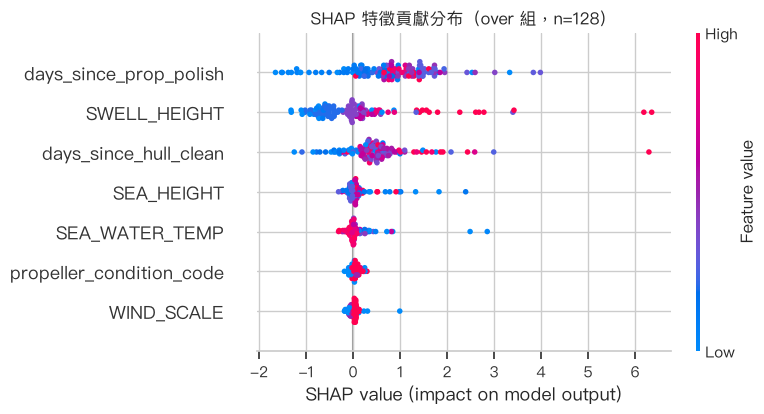

In [26]:
# SHAP summary plot：每個特徵對「油耗偏高」的貢獻分布，顏色=特徵數值高低
shap.summary_plot(shap_values, X_over, feature_names=ROOT_CAUSE_FEATURES, show=False)
plt.title('SHAP 特徵貢獻分布（over 組，n=128）')
plt.tight_layout(); plt.show()